In [1]:
import tensorflow as tf
import torch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.18.0


In [2]:
!pip install optuna
import optuna
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import DistilBertTokenizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.5 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()


data = pd.read_csv('yelp_review_100k.csv', nrows=70000)

Saving yelp_review_100k.csv to yelp_review_100k.csv


In [4]:
# Display dataset structure
print(data.head())

                                                text  stars sentiment
0  If you decide to eat here, just be aware it is...      3   neutral
1  I've taken a lot of spin classes over the year...      5  positive
2  Family diner. Had the buffet. Eclectic assortm...      3   neutral
3  Wow!  Yummy, different,  delicious.   Our favo...      5  positive
4  Cute interior and owner (?) gave us tour of up...      4  positive


In [5]:
# Preprocessing function
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    text = text.lower()  # Convert to lowercase
    text = text.strip()  # Remove leading/trailing whitespace
    return text

In [6]:
# Apply preprocessing
data['cleaned_text'] = data['text'].apply(preprocess_text)

In [7]:
# Tokenization for DistilBERT
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
data['distilbert_tokens'] = data['cleaned_text'].apply(lambda x: distilbert_tokenizer.encode(x, truncation=True, padding='max_length', max_length=100))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [8]:
# Splitting dataset
X_distilbert = np.array(data['distilbert_tokens'].tolist())
y = data['sentiment']

In [9]:
X_train_distilbert, X_test_distilbert, y_train_distilbert, y_test_distilbert = train_test_split(
    X_distilbert, y, test_size=0.2, random_state=42
)

In [10]:
# Save preprocessed data for later use
np.save('X_train_distilbert.npy', X_train_distilbert)
np.save('X_test_distilbert.npy', X_test_distilbert)

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

def model_init():
    from transformers import DistilBertForSequenceClassification
    return DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

In [12]:
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 2e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.3),
    }

In [13]:
# Example label mapping
label_map = {"negative": 0, "neutral": 1, "positive": 2}

# Apply mapping if necessary
y_train_distilbert = [label_map[label] if isinstance(label, str) else label for label in y_train_distilbert]
y_test_distilbert = [label_map[label] if isinstance(label, str) else label for label in y_test_distilbert]

In [14]:
!pip install datasets

from datasets import Dataset

train_data = {"text": X_train_distilbert, "label": y_train_distilbert}
val_data = {"text": X_test_distilbert, "label": y_test_distilbert}

# Convert to Hugging Face Datasets
train_dataset = Dataset.from_dict(train_data)
val_dataset = Dataset.from_dict(val_data)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [15]:
def tokenize_function(example):
    return distilbert_tokenizer(example["text"], padding="max_length", truncation=True)

# Convert NumPy arrays to lists of strings for compatibility
train_dataset = Dataset.from_dict({"text": [" ".join(map(str, x)) for x in train_dataset["text"]], "label": train_dataset["label"]})
val_dataset = Dataset.from_dict({"text": [" ".join(map(str, x)) for x in val_dataset["text"]], "label": val_dataset["label"]})

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/56000 [00:00<?, ? examples/s]

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

In [16]:
print(train_dataset[0]["label"])
print(type(train_dataset[0]["label"]))

tensor(2)
<class 'torch.Tensor'>


In [17]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    per_device_train_batch_size=32,  # KEEP consistent
    per_device_eval_batch_size=64,  # KEEP consistent
    fp16=True if torch.cuda.is_available() else False,
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=distilbert_tokenizer,
    compute_metrics=compute_metrics,
)

best_run = trainer.hyperparameter_search(
    direction="maximize",
    hp_space=optuna_hp_space,
    n_trials=10,
    backend="optuna"
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-17-e7882ce08d8d>:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-04-08 12:38:13,339] A new study created in memory with name: no-name-1c96e4ba-6426-4a14-81d8-5ec7fb822f4a
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: solarosflame (solarosflame-humber-college) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.621200,0.610968,0.769286


[I 2025-04-08 14:25:30,576] Trial 8 pruned. 
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


eval/accuracy,▁
eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁▂▃▅▆▇██
train/global_step,▁▂▃▅▆▇██
train/grad_norm,▁▅▃▂▃▅█
train/learning_rate,█▇▆▄▃▂▁
train/loss,█▆▅▃▂▂▁
eval/accuracy,0.76929


Epoch,Training Loss,Validation Loss,Accuracy
1,0.561600,0.533367,0.788500


[I 2025-04-08 14:28:18,958] Trial 9 pruned. 


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from trainer
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Print metrics
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.70      0.60      0.65      2611
     Neutral       0.40      0.09      0.15      1620
    Positive       0.82      0.95      0.88      9769

    accuracy                           0.79     14000
   macro avg       0.64      0.55      0.56     14000
weighted avg       0.75      0.79      0.75     14000



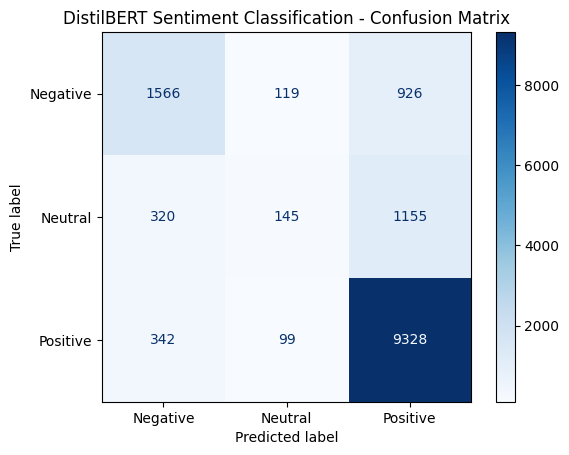

In [19]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("DistilBERT Sentiment Classification - Confusion Matrix")
plt.show()


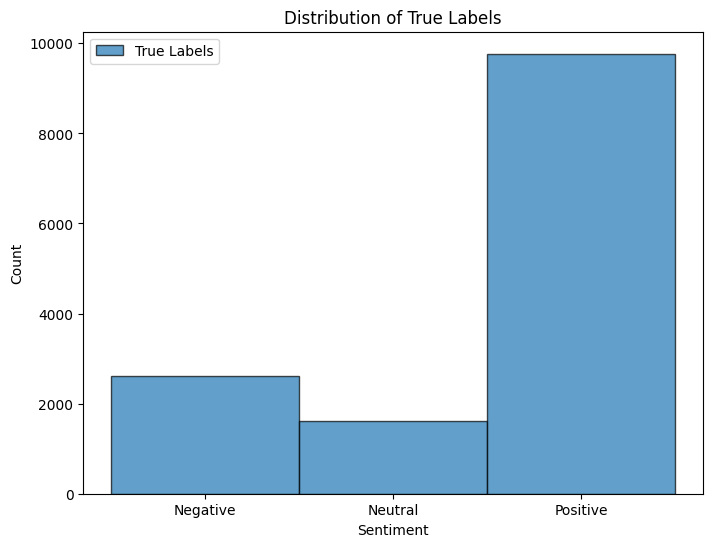

In [20]:
# Visualize the distribution of true labels
plt.figure(figsize=(8, 6))
plt.hist(y_true, bins=np.arange(4) - 0.5, edgecolor='black', alpha=0.7, label='True Labels')
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.title("Distribution of True Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.legend()
plt.show()

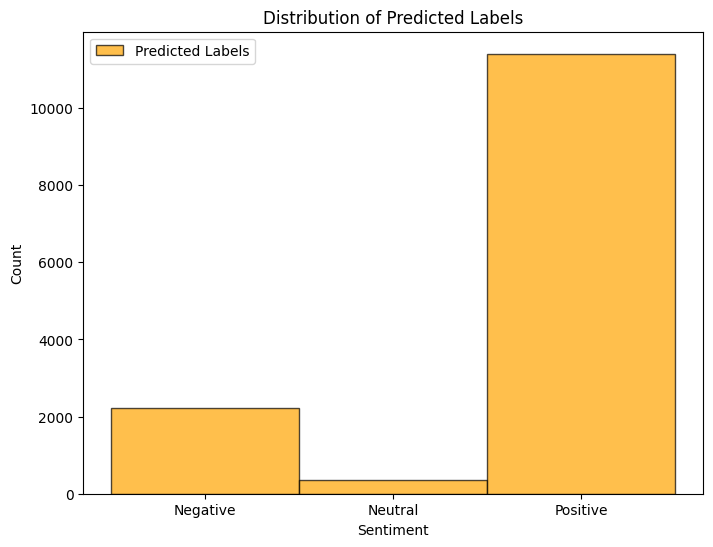

In [21]:
# Visualize the distribution of predicted labels
plt.figure(figsize=(8, 6))
plt.hist(y_pred, bins=np.arange(4) - 0.5, edgecolor='black', alpha=0.7, label='Predicted Labels', color='orange')
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.title("Distribution of Predicted Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.legend()
plt.show()

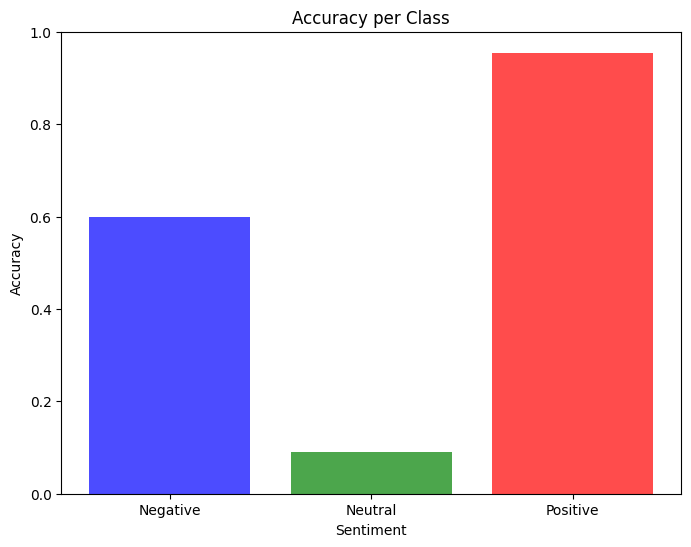

In [22]:
# Bar plot for accuracy per class
class_accuracies = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 6))
plt.bar(["Negative", "Neutral", "Positive"], class_accuracies, color=['blue', 'green', 'red'], alpha=0.7)
plt.title("Accuracy per Class")
plt.xlabel("Sentiment")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

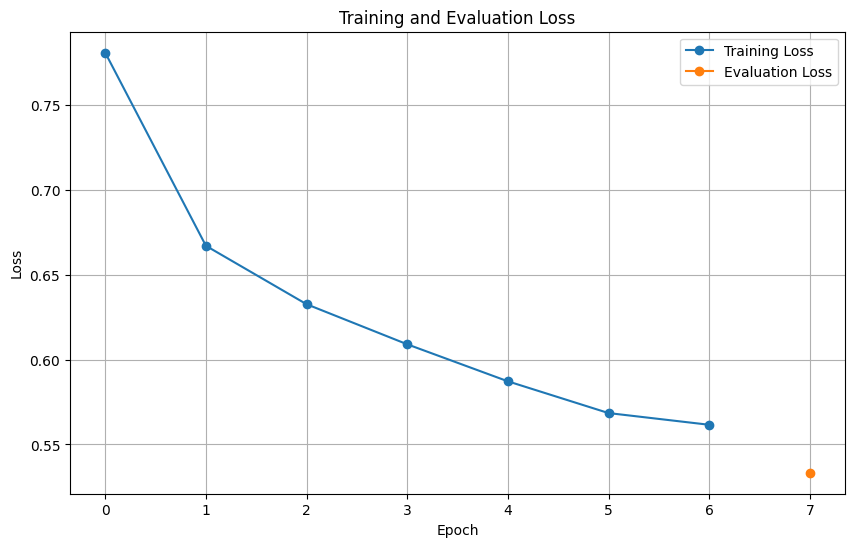

In [23]:
# Extract training logs
logs = trainer.state.log_history

# Convert logs to a DataFrame for easier plotting
logs_df = pd.DataFrame(logs)

# Plot training and evaluation loss
plt.figure(figsize=(10, 6))
if "loss" in logs_df.columns:
    plt.plot(logs_df[logs_df["loss"].notnull()]["loss"], label="Training Loss", marker='o')
if "eval_loss" in logs_df.columns:
    plt.plot(logs_df[logs_df["eval_loss"].notnull()]["eval_loss"], label="Evaluation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Evaluation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from optuna.visualization import plot_param_importances

# Generate the hyperparameter importance plot
fig = plot_param_importances(study)
fig.show()